In [5]:
import pandas as pd 
import numpy as np
import seaborn as sns

In [6]:
df = pd.read_csv("Healthinsurance.csv")

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='bmi', ylabel='charges'>

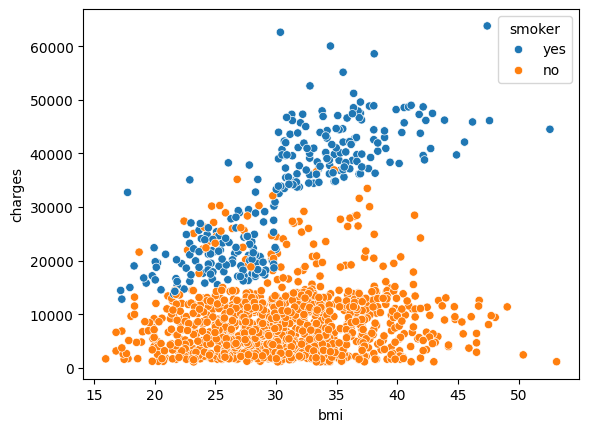

In [8]:
#  visualize the dsta
sns.scatterplot(x=df["bmi"],y=df["charges"],hue=df["smoker"])
#  jha pe smoker hain wah compamny jyada spend krri hain charges and jha km hain smoker wah km spend krri hain

In [9]:
X= df.drop(columns = ["charges","region"] )
y = df["charges"]

X["sex"] = X["sex"].map({"female":1,"male":0})
X["smoker"] = X["smoker"].map({"yes":1,"no":0})

In [10]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
#  train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size = 0.2,random_state=42)


In [12]:
X_test.head()

,age,sex,bmi,children,smoker
764,45,1,25.175,2,0
887,36,1,30.020,0,0
890,64,1,26.885,0,1
1293,46,0,25.745,3,0
259,19,0,31.920,0,1


In [13]:
#  training the model
#  inear regression function
from sklearn.linear_model import LinearRegression
model =  LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
#  predicted values 
y_pred = model.predict(X_test)

In [15]:


y_pred
#  Xtest ke iye predict value agyi 


array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [16]:
y_test
#  y ki actul values hain


764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [17]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(f"r2_score :{r2}")
#  r2 to predict 78% model shi hain'
n =  X_test.shape[0]
p =  X_test.shape[1]
adjusted_r_squared =1 - ((1-r2) *(n-1)/(n-p-1))
print(f"adjusetd_r_squared:{adjusted_r_squared}")
#  r2 se thoda km hain adjusted_r_score hain


r2_score :0.7811302113434095
adjusetd_r_squared:0.7769533069797342


In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
#  feature encoding
X= df.drop(columns = ["charges"] )
y = df["charges"]
X = pd.get_dummies(X,columns = ["region"],drop_first=True,dtype=int)
X["sex"] = X["sex"].map({"female":1,"male":0})
X["smoker"] = X["smoker"].map({"yes":1,"no":0})
#  dtype se int 1,0 values agyi hain
#  one hot encoding

In [20]:
X.sample(10)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
548,25,1,28.595,0,0,0,0,0
1076,47,1,32.000,1,0,0,0,1
687,40,0,41.690,0,0,0,1,0
35,19,0,20.425,0,0,1,0,0
1092,23,0,32.700,3,0,0,0,1
468,28,1,24.320,1,0,0,0,0
923,34,0,35.815,0,0,1,0,0
1111,38,0,38.390,3,1,0,1,0
1094,50,1,33.700,4,0,0,0,1
629,44,1,38.950,0,1,1,0,0


In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size = 0.2,random_state=42)

from sklearn.linear_model import LinearRegression
model =  LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(f"r2_score :{r2}")


r2_score :0.7835929767120724


In [23]:
#  interaction Features

X= df.drop(columns = ["charges"] )
y = df["charges"]
X = pd.get_dummies(X,columns = ["region"],drop_first=True,dtype=int)
X["sex"] = X["sex"].map({"female":1,"male":0})
X["smoker"] = X["smoker"].map({"yes":1,"no":0})
X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

In [24]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size = 0.2,random_state=42)

from sklearn.linear_model import LinearRegression
model =  LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(f"r2_score :{r2}")


r2_score :0.865231697953168


In [33]:
#  underfit & overfit
#  r2 is low  training data low -> underfit
#  r2 is low  testing data low -> underfit
#  r2 training data >> r2 testing data -> overfit
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train,y_train_pred)

print("training data r2:" , r2_train)
print("test r2:" , r2)

#  good petrformance 

training data r2: 0.8340713711218875
test r2: 0.865231697953168


In [34]:
df.shape

(1338, 7)